In [1]:
import os
from pathlib import Path
import copy
import numpy as np
import torch

from pcdet.config import cfg, cfg_from_yaml_file
from pcdet.models import build_network, load_data_to_gpu
from pcdet.datasets import build_dataloader
from pcdet.utils import common_utils
import random

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

import helpers
import importlib

from collections import defaultdict

importlib.reload(helpers)

/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:243: Futur

<module 'helpers' from '/storage/project/r-gchou3-0/spanse30/OpenPCDet/helpers.py'>

In [2]:
CFG_FILE = 'tools/cfgs/waymo_models/centerpoint.yaml' 
CKPT = 'output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth'  # <- put your ckpt here

cfg_from_yaml_file(CFG_FILE, cfg)
cfg.TAG = Path(CFG_FILE).stem
cfg.EXP_GROUP_PATH = 'centerpoint_waymo_demo'

logger = common_utils.create_logger()
logger.info(f'Loaded cfg from {CFG_FILE}')

dataset, test_loader, _ = build_dataloader(
    dataset_cfg=cfg.DATA_CONFIG,
    class_names=cfg.CLASS_NAMES,
    batch_size=1,
    dist=False,
    workers=4,
    logger=logger,
    training=False
)

len_test = len(dataset)
logger.info(f'Test set length: {len_test}')
model = build_network(
    model_cfg=cfg.MODEL,
    num_class=len(cfg.CLASS_NAMES),
    dataset=dataset
)

logger.info(f'Loading checkpoint from: {CKPT}')
model.load_params_from_file(filename=CKPT, logger=logger, to_cpu=False)
model.cuda()
model.eval()

data_iter = iter(test_loader)
batch_dict = next(data_iter)

load_data_to_gpu(batch_dict)

# Sanity check shapes
print('points:', batch_dict['points'].shape)         # [N, 5] -> [batch_idx, x, y, z, i]
print('voxels:', batch_dict['voxels'].shape)         # [V, T, C]
print('voxel_coords:', batch_dict['voxel_coords'].shape)  # [V, 4] -> [b, z, y, x]
print('voxel_num_points:', batch_dict['voxel_num_points'].shape)  # [V]

2026-01-31 16:37:14,263   INFO  Loaded cfg from tools/cfgs/waymo_models/centerpoint.yaml
2026-01-31 16:37:14,299   INFO  Loading Waymo dataset
2026-01-31 16:37:35,772   INFO  Total skipped info 0
2026-01-31 16:37:35,773   INFO  Total samples for Waymo dataset: 38597
2026-01-31 16:37:35,774   INFO  Test set length: 38597
2026-01-31 16:37:37,191   INFO  Loading checkpoint from: output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth
2026-01-31 16:37:37,235   INFO  ==> Loading parameters from checkpoint output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth to GPU
/storage/project/r-gchou3-0/spanse30/OpenPCDet/pcdet/models/detectors/detector3d_template.py:367: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https:

points: torch.Size([126501, 6])
voxels: torch.Size([75604, 5, 5])
voxel_coords: torch.Size([75604, 4])
voxel_num_points: torch.Size([75604])


In [3]:
# traces = []
# for i in range(0, 100):
#     boxes = dataset[i]['gt_boxes']
#     points = dataset[i]['points']
#     mask = boxes[:, 7]==1
#     boxes_car = boxes[mask]

#     extracted_traces = []
#     for box in boxes_car:
#         cx, cy, cz = box[0], box[1], box[2]
#         dx, dy, dz = box[3], box[4], box[5]
#         heading = box[6]

#         #put box center at origin
#         shifted_points = points[:, :3] - np.array([cx, cy, cz])

#         #rotate points to align with the box's local axes
#         #rotate by -heading to undo boxes rotation
#         cos_a = np.cos(-heading)
#         sin_a = np.sin(-heading)
#         R = np.array([
#             [cos_a, -sin_a, 0],
#             [sin_a,  cos_a, 0],
#             [0,      0,     1]])
#         local_points = shifted_points@R.T
#         inside_mask = (
#             (np.abs(local_points[:, 0]) <= dx / 2) &
#             (np.abs(local_points[:, 1]) <= dy / 2) &
#             (np.abs(local_points[:, 2]) <= dz / 2)
#         )
#         points_inside = points[inside_mask]
#         if len(points_inside) > 0:
#             extracted_traces.append({
#                 'frame': i,
#                 'box': box,
#                 'points': points_inside,
#                 'num_points': len(points_inside)
#             })
#     # print(f"=============frame {i}============")
#     for trace in extracted_traces:
#     # print(trace['points'])
#         # print(trace['num_points'], np.linalg.norm(trace['box'][:3]))
#         if(trace['num_points'] <= 100): traces.append(trace)

# # for i, trace in enumerate(traces):
# #     print(i, trace['frame'], trace['num_points'])
traces_smaller = []

flag = 0
for i in range(0, 100):
    boxes = dataset[i]['gt_boxes']
    points = dataset[i]['points']
    mask = boxes[:, 7]==1
    boxes_car = boxes[mask]

    extracted_traces = []
    for box in boxes_car:
        cx, cy, cz = box[0], box[1], box[2]
        dx, dy, dz = box[3], box[4], box[5]
        heading = box[6]

        #put box center at origin
        shifted_points = points[:, :3] - np.array([cx, cy, cz])

        #rotate points to align with the box's local axes
        #rotate by -heading to undo boxes rotation
        cos_a = np.cos(-heading)
        sin_a = np.sin(-heading)
        R = np.array([
            [cos_a, -sin_a, 0],
            [sin_a,  cos_a, 0],
            [0,      0,     1]])
        local_points = shifted_points@R.T
        inside_mask = (
            (np.abs(local_points[:, 0]) <= dx / 2) &
            (np.abs(local_points[:, 1]) <= dy / 2) &
            (np.abs(local_points[:, 2]) <= dz / 2)
        )
        points_inside = points[inside_mask]
        if len(points_inside) > 0:
            extracted_traces.append({
                'frame': i,
                'box': box,
                'points': points_inside,
                'num_points': len(points_inside)
            })
    # print(f"=============frame {i}============")
    for trace in extracted_traces:
    # print(trace['points'])
        # print(trace['num_points'], np.linalg.norm(trace['box'][:3]))
        if(trace['num_points'] <= 100 and trace['num_points'] >=30): traces_smaller.append(trace)
        if(len(traces_smaller) == 100):
            flag = 1
            break
    if(flag): break

    # if(len(traces) == 100): break
    
traces_bigger = []
flag = 0
for i in range(0, 100):
    boxes = dataset[i]['gt_boxes']
    points = dataset[i]['points']
    mask = boxes[:, 7]==1
    boxes_car = boxes[mask]

    extracted_traces = []
    for box in boxes_car:
        cx, cy, cz = box[0], box[1], box[2]
        dx, dy, dz = box[3], box[4], box[5]
        heading = box[6]

        #put box center at origin
        shifted_points = points[:, :3] - np.array([cx, cy, cz])

        #rotate points to align with the box's local axes
        #rotate by -heading to undo boxes rotation
        cos_a = np.cos(-heading)
        sin_a = np.sin(-heading)
        R = np.array([
            [cos_a, -sin_a, 0],
            [sin_a,  cos_a, 0],
            [0,      0,     1]])
        local_points = shifted_points@R.T
        inside_mask = (
            (np.abs(local_points[:, 0]) <= dx / 2) &
            (np.abs(local_points[:, 1]) <= dy / 2) &
            (np.abs(local_points[:, 2]) <= dz / 2)
        )
        points_inside = points[inside_mask]
        if len(points_inside) > 0:
            extracted_traces.append({
                'frame': i,
                'box': box,
                'points': points_inside,
                'num_points': len(points_inside)
            })
    # print(f"=============frame {i}============")
    for trace in extracted_traces:
    # print(trace['points'])
        # print(trace['num_points'], np.linalg.norm(trace['box'][:3]))
        if(trace['num_points'] <= 200 and trace['num_points'] >=100): traces_bigger.append(trace)
        if(len(traces_bigger) == 100):
            flag = 1
            break
    if(flag): break

# for i, trace in enumerate(traces):
#     print(i, trace['frame'], trace['num_points'])

In [4]:
importlib.reload(helpers)

<module 'helpers' from '/storage/project/r-gchou3-0/spanse30/OpenPCDet/helpers.py'>

In [13]:
# TODO: ONLY ROTATE IF ORIGINAL TRACE POSITION IS BEHIND EGO
frame = 50
dict_clean = dataset[frame]
dict_clean = helpers.inject_gt_names(dict_clean, dataset.class_names)
dict_clean = dataset.prepare_data(dict_clean)
dict_clean['batch_size'] = 1
load_data_to_gpu(dict_clean)
batch_clean = helpers.convert_to_batch(dict_clean)
model.eval()
with torch.no_grad():
    pred_clean, _ = model.forward(batch_clean)

In [14]:
len(traces)

348

In [5]:
frame = 50
spoof_data_smaller= []
spoof_data_bigger= []
failed_attempts_smaller = []
failed_attempts_bigger = []

In [7]:
for i, trace in enumerate(traces_smaller):    
    selected_trace = trace
    centered_points_trace = selected_trace['points'][:, :2] - selected_trace['box'][:2]
    position = np.array([15, -3])

    angle = 0
    if(selected_trace['box'][0]<0):
        # print("rear object")
        angle = np.pi

    c = np.cos(angle)
    s = np.sin(angle)
    R = np.array([[c, -s],
                  [s, c]])


    rotated_trace = centered_points_trace @ R.T
    front_near_trace_planar = rotated_trace + position
    front_near_trace = np.concatenate([front_near_trace_planar, selected_trace['points'][:, 2].reshape(-1, 1)], axis = 1)

    # helpers.plot_trace(front_near_trace)

    importlib.reload(helpers)
    r_trace, theta_trace, phi_trace = helpers.cart_2_spherical(front_near_trace)
    scene_points = dataset[frame]['points'][:, :3]
    r_scene, theta_scene, phi_scene = helpers.cart_2_spherical(scene_points)

    trace_spherical = np.concatenate([r_trace.reshape(-1, 1), theta_trace.reshape(-1, 1), phi_trace.reshape(-1, 1)], axis = 1)
    scene_spherical = np.concatenate([r_scene.reshape(-1, 1), theta_scene.reshape(-1, 1), phi_scene.reshape(-1, 1)], axis = 1)

    azimuths = np.deg2rad(np.arange(0, 360.1, np.deg2rad(0.1358)))
    elevations = np.load('waymo_top_lidar_inclinations.npy')


    Grid = defaultdict(list)
    dtheta = np.deg2rad(0.1358)
    for idx, (r, theta, phi) in enumerate(scene_spherical):
        az = theta % (2*np.pi)
        az_idx = int(np.floor(az/dtheta))
        beam_idx = np.argmin(np.abs(elevations-phi))
        Grid[(az_idx, beam_idx)].append((r, idx))
    for key in Grid:
        Grid[key].sort(key=lambda x: x[0])  # sort by range


    remove_spoof = []
    remove_scene = []
    for idx, (r, theta, phi) in enumerate(trace_spherical):
        az = theta % (2*np.pi)
        az_idx = int(np.floor(az/dtheta))
        beam_idx = np.argmin(np.abs(elevations-phi))
        returns = Grid[(az_idx, beam_idx)]
        if(len(returns) == 0):
            continue
        else:
            # spoof point is behind first real return, remove it
            if returns[0][0] < r:
                # print(round(azimuths[az_idx], 4), round(elevations[beam_idx], 4), round(r, 4), returns[0][0], returns[0][1])
                #ranges are already sorted in ascending order
                remove_spoof.append(idx)
            #spoof is front of all real returns
            elif r < returns[0][0]:
                for element in returns:
                    remove_scene.append(element[1]) #remove all scene points 
            #spoof is between two real returns
            else:
                for k, (r_scene, idx_scene) in enumerate(returns):
                    if r_scene > r:
                        # keep spoof
                        for element in returns[k:]:
                            remove_scene.append(element[1])
                        break 
    # print(trace_spherical.shape[0], remove_spoof)



    fn_points = np.concatenate([front_near_trace, selected_trace['points'][:, -2:]], axis = 1)
    scene_points = dataset[frame]['points'] 

    mask_remove_spoof = np.ones(fn_points.shape[0], dtype=bool)
    mask_remove_spoof[remove_spoof] = False
    fn_points_rc = fn_points[mask_remove_spoof]

    mask_remove_scene = np.ones(scene_points.shape[0], dtype=bool)
    mask_remove_scene[remove_scene] = False
    scene_points_rc = scene_points[mask_remove_scene]

    frame_points_spoof_rc = np.concatenate([scene_points_rc, fn_points_rc], axis = 0)



    # 2. Reload fresh data to be safe (aliasing prevention)
    dict_mod = dataset[frame] # Currently identical to clean

    # 3. Inject the spoofed points
    # Ensure shape is (N, 4) or (N, 5) matching the original
    dict_mod['points'] = frame_points_spoof_rc

    # 4. Remove old voxel data 
    # (Since we changed points, old voxels are invalid. 
    # prepare_data usually overwrites, but this prevents shape mismatch errors)
    for k in ['voxels', 'voxel_coords', 'voxel_num_points']:
        dict_mod.pop(k, None)

    # 5. Inject the missing 'gt_names'
    dict_mod   = helpers.inject_gt_names(dict_mod, dataset.class_names)
    dict_mod   = dataset.prepare_data(dict_mod)
    dict_mod['batch_size']   = 1

    load_data_to_gpu(dict_mod)
    batch_mod = helpers.convert_to_batch(dict_mod)

    model.eval()
    with torch.no_grad():
        pred_mod, _   = model.forward(batch_mod)
    # print("clean num boxes:", pred_clean[0]['pred_boxes'].shape[0])
    # print("mod   num boxes:", pred_mod[0]['pred_boxes'].shape[0])
    # Look at the raw scores before filtering
    raw_scores = pred_mod[0]['pred_scores']

    # candidate = []
    # for i in range (0, pred_mod[0]['pred_boxes'].shape[0]):
    #     x = pred_mod[0]['pred_boxes'][:, 0]
    #     y = pred_mod[0]['pred_boxes'][:, 1]
    #     if(x[i] >= 13 and x[i]<=17 and y[i]>=-5 and y[i]<=-1):
    #         candidate.append(i)
    #         print("prediction: ", i," |box location: ",  pred_mod[0]['pred_boxes'][i], " |score: ", pred_mod[0]['pred_scores'][3], " |label: ", pred_mod[0]['pred_labels'][3])



    pos_t = torch.from_numpy(position).to('cuda')
    val_t = torch.tensor([selected_trace['box'][2]], device='cuda')
    box_dim = torch.from_numpy(selected_trace['box'][3:6]).to('cuda')
    trace_box_c = torch.cat((pos_t, val_t, box_dim))
    d_trace = torch.linalg.norm(trace_box_c[:3])
    V_trace = selected_trace['box'][3]*selected_trace['box'][4]*selected_trace['box'][5]

    comparisons = []

    for i in range (0, pred_mod[0]['pred_boxes'].shape[0]):
        box = pred_mod[0]['pred_boxes'][i][:3]
        dim = pred_mod[0]['pred_boxes'][i][3:6]
        d_pred = torch.linalg.norm(box)
        V_pred = dim[0]*dim[1]*dim[2]
        label_pred = pred_mod[0]['pred_labels'][i].item()
        score_pred = pred_mod[0]['pred_scores'][i].item()

        d_d = np.round(torch.abs(d_pred - d_trace).item(), 2)
        d_V = np.round(torch.abs(V_pred - V_trace).item(), 2)
        d_label = label_pred - 1

        cos = helpers.cosine_similarity(trace_box_c[:3].float(), box)
        data = {
            "box" : box,
            "dim" : dim, 
            "distance" : d_d,
            "cos_sim" : cos,
            "volume" : d_V,
            "label" : label_pred,
            "score" : score_pred,
            "n_points": selected_trace['num_points']
        }
        comparisons.append(data)
        # print(f"index = {i} | d_distance: {d_d} | cos similarity: {np.round(cos.item(), 2)} | d_Volume:{d_V} | d_label: {d_label} | score: {np.round(score_pred, 2)}")

    best_idx = sorted(
        range(len(comparisons)),
        key=lambda i: (
            comparisons[i]["distance"],
            -comparisons[i]["cos_sim"],
            comparisons[i]["volume"]
        )
    )[0]

    # print("Best match index:", best_idx)
    if(comparisons[best_idx]['cos_sim'].item() > 0):
        print(f"n points: {selected_trace['num_points']} ", comparisons[best_idx])
        spoof_data_smaller.append(comparisons[best_idx])
    else:
        failed_attempts_smaller.append(comparisons[best_idx])
        print(f"NO PROPOSALS FOUND FOR TRACE WITH {trace['num_points']}")
        # print(box)
    # print(pred_mod[0]['pred_boxes'][best_idx])
    # print(trace_box_c)

n points: 93  {'box': tensor([14.8576, -3.0488,  0.9322], device='cuda:0'), 'dim': tensor([4.6710, 2.0362, 1.5051], device='cuda:0'), 'distance': 0.13, 'cos_sim': tensor(1.0000, device='cuda:0'), 'volume': 0.51, 'label': 1, 'score': 0.9104835391044617, 'n_points': 93}
n points: 34  {'box': tensor([14.8831, -3.0693,  1.1021], device='cuda:0'), 'dim': tensor([4.7411, 2.1217, 1.6872], device='cuda:0'), 'distance': 0.09, 'cos_sim': tensor(0.9999, device='cuda:0'), 'volume': 3.17, 'label': 1, 'score': 0.839952826499939, 'n_points': 34}
n points: 31  {'box': tensor([14.7731, -3.3164,  0.9883], device='cuda:0'), 'dim': tensor([4.5485, 2.0458, 1.5480], device='cuda:0'), 'distance': 0.15, 'cos_sim': tensor(0.9997, device='cuda:0'), 'volume': 0.6, 'label': 1, 'score': 0.5373139977455139, 'n_points': 31}
n points: 32  {'box': tensor([15.0195, -2.8630,  0.7622], device='cuda:0'), 'dim': tensor([4.4274, 2.0463, 1.4873], device='cuda:0'), 'distance': 0.01, 'cos_sim': tensor(1.0000, device='cuda:0'),

In [8]:
for i, trace in enumerate(traces_bigger):    
    selected_trace = trace
    centered_points_trace = selected_trace['points'][:, :2] - selected_trace['box'][:2]
    position = np.array([15, -3])

    angle = 0
    if(selected_trace['box'][0]<0):
        # print("rear object")
        angle = np.pi

    c = np.cos(angle)
    s = np.sin(angle)
    R = np.array([[c, -s],
                  [s, c]])


    rotated_trace = centered_points_trace @ R.T
    front_near_trace_planar = rotated_trace + position
    front_near_trace = np.concatenate([front_near_trace_planar, selected_trace['points'][:, 2].reshape(-1, 1)], axis = 1)

    # helpers.plot_trace(front_near_trace)

    importlib.reload(helpers)
    r_trace, theta_trace, phi_trace = helpers.cart_2_spherical(front_near_trace)
    scene_points = dataset[frame]['points'][:, :3]
    r_scene, theta_scene, phi_scene = helpers.cart_2_spherical(scene_points)

    trace_spherical = np.concatenate([r_trace.reshape(-1, 1), theta_trace.reshape(-1, 1), phi_trace.reshape(-1, 1)], axis = 1)
    scene_spherical = np.concatenate([r_scene.reshape(-1, 1), theta_scene.reshape(-1, 1), phi_scene.reshape(-1, 1)], axis = 1)

    azimuths = np.deg2rad(np.arange(0, 360.1, np.deg2rad(0.1358)))
    elevations = np.load('waymo_top_lidar_inclinations.npy')


    Grid = defaultdict(list)
    dtheta = np.deg2rad(0.1358)
    for idx, (r, theta, phi) in enumerate(scene_spherical):
        az = theta % (2*np.pi)
        az_idx = int(np.floor(az/dtheta))
        beam_idx = np.argmin(np.abs(elevations-phi))
        Grid[(az_idx, beam_idx)].append((r, idx))
    for key in Grid:
        Grid[key].sort(key=lambda x: x[0])  # sort by range


    remove_spoof = []
    remove_scene = []
    for idx, (r, theta, phi) in enumerate(trace_spherical):
        az = theta % (2*np.pi)
        az_idx = int(np.floor(az/dtheta))
        beam_idx = np.argmin(np.abs(elevations-phi))
        returns = Grid[(az_idx, beam_idx)]
        if(len(returns) == 0):
            continue
        else:
            # spoof point is behind first real return, remove it
            if returns[0][0] < r:
                # print(round(azimuths[az_idx], 4), round(elevations[beam_idx], 4), round(r, 4), returns[0][0], returns[0][1])
                #ranges are already sorted in ascending order
                remove_spoof.append(idx)
            #spoof is front of all real returns
            elif r < returns[0][0]:
                for element in returns:
                    remove_scene.append(element[1]) #remove all scene points 
            #spoof is between two real returns
            else:
                for k, (r_scene, idx_scene) in enumerate(returns):
                    if r_scene > r:
                        # keep spoof
                        for element in returns[k:]:
                            remove_scene.append(element[1])
                        break 
    # print(trace_spherical.shape[0], remove_spoof)



    fn_points = np.concatenate([front_near_trace, selected_trace['points'][:, -2:]], axis = 1)
    scene_points = dataset[frame]['points'] 

    mask_remove_spoof = np.ones(fn_points.shape[0], dtype=bool)
    mask_remove_spoof[remove_spoof] = False
    fn_points_rc = fn_points[mask_remove_spoof]

    mask_remove_scene = np.ones(scene_points.shape[0], dtype=bool)
    mask_remove_scene[remove_scene] = False
    scene_points_rc = scene_points[mask_remove_scene]

    frame_points_spoof_rc = np.concatenate([scene_points_rc, fn_points_rc], axis = 0)



    # 2. Reload fresh data to be safe (aliasing prevention)
    dict_mod = dataset[frame] # Currently identical to clean

    # 3. Inject the spoofed points
    # Ensure shape is (N, 4) or (N, 5) matching the original
    dict_mod['points'] = frame_points_spoof_rc

    # 4. Remove old voxel data 
    # (Since we changed points, old voxels are invalid. 
    # prepare_data usually overwrites, but this prevents shape mismatch errors)
    for k in ['voxels', 'voxel_coords', 'voxel_num_points']:
        dict_mod.pop(k, None)

    # 5. Inject the missing 'gt_names'
    dict_mod   = helpers.inject_gt_names(dict_mod, dataset.class_names)
    dict_mod   = dataset.prepare_data(dict_mod)
    dict_mod['batch_size']   = 1

    load_data_to_gpu(dict_mod)
    batch_mod = helpers.convert_to_batch(dict_mod)

    model.eval()
    with torch.no_grad():
        pred_mod, _   = model.forward(batch_mod)
    # print("clean num boxes:", pred_clean[0]['pred_boxes'].shape[0])
    # print("mod   num boxes:", pred_mod[0]['pred_boxes'].shape[0])
    # Look at the raw scores before filtering
    raw_scores = pred_mod[0]['pred_scores']

    # candidate = []
    # for i in range (0, pred_mod[0]['pred_boxes'].shape[0]):
    #     x = pred_mod[0]['pred_boxes'][:, 0]
    #     y = pred_mod[0]['pred_boxes'][:, 1]
    #     if(x[i] >= 13 and x[i]<=17 and y[i]>=-5 and y[i]<=-1):
    #         candidate.append(i)
    #         print("prediction: ", i," |box location: ",  pred_mod[0]['pred_boxes'][i], " |score: ", pred_mod[0]['pred_scores'][3], " |label: ", pred_mod[0]['pred_labels'][3])



    pos_t = torch.from_numpy(position).to('cuda')
    val_t = torch.tensor([selected_trace['box'][2]], device='cuda')
    box_dim = torch.from_numpy(selected_trace['box'][3:6]).to('cuda')
    trace_box_c = torch.cat((pos_t, val_t, box_dim))
    d_trace = torch.linalg.norm(trace_box_c[:3])
    V_trace = selected_trace['box'][3]*selected_trace['box'][4]*selected_trace['box'][5]

    comparisons = []

    for i in range (0, pred_mod[0]['pred_boxes'].shape[0]):
        box = pred_mod[0]['pred_boxes'][i][:3]
        dim = pred_mod[0]['pred_boxes'][i][3:6]
        d_pred = torch.linalg.norm(box)
        V_pred = dim[0]*dim[1]*dim[2]
        label_pred = pred_mod[0]['pred_labels'][i].item()
        score_pred = pred_mod[0]['pred_scores'][i].item()

        d_d = np.round(torch.abs(d_pred - d_trace).item(), 2)
        d_V = np.round(torch.abs(V_pred - V_trace).item(), 2)
        d_label = label_pred - 1

        cos = helpers.cosine_similarity(trace_box_c[:3].float(), box)
        data = {
            "box" : box,
            "dim" : dim, 
            "distance" : d_d,
            "cos_sim" : cos,
            "volume" : d_V,
            "label" : label_pred,
            "score" : score_pred,
            "n_points": selected_trace['num_points']
        }
        comparisons.append(data)
        # print(f"index = {i} | d_distance: {d_d} | cos similarity: {np.round(cos.item(), 2)} | d_Volume:{d_V} | d_label: {d_label} | score: {np.round(score_pred, 2)}")

    best_idx = sorted(
        range(len(comparisons)),
        key=lambda i: (
            comparisons[i]["distance"],
            -comparisons[i]["cos_sim"],
            comparisons[i]["volume"]
        )
    )[0]

    # print("Best match index:", best_idx)
    if(comparisons[best_idx]['cos_sim'].item() > 0):
        print(f"n points: {selected_trace['num_points']} ", comparisons[best_idx])
        spoof_data_bigger.append(comparisons[best_idx])
    else:
        failed_attempts_bigger.append(comparisons[best_idx])
        print(f"NO PROPOSALS FOUND FOR TRACE WITH {trace['num_points']}")
        # print(box)
    # print(pred_mod[0]['pred_boxes'][best_idx])
    # print(trace_box_c)

n points: 114  {'box': tensor([14.7904, -3.0548,  0.8286], device='cuda:0'), 'dim': tensor([4.5219, 1.9973, 1.4940], device='cuda:0'), 'distance': 0.19, 'cos_sim': tensor(1.0000, device='cuda:0'), 'volume': 0.31, 'label': 1, 'score': 0.91007399559021, 'n_points': 114}
n points: 111  {'box': tensor([14.9938, -3.0253,  0.8904], device='cuda:0'), 'dim': tensor([4.6697, 2.1300, 1.4580], device='cuda:0'), 'distance': 0.01, 'cos_sim': tensor(1.0000, device='cuda:0'), 'volume': 1.12, 'label': 1, 'score': 0.8722473978996277, 'n_points': 111}
n points: 124  {'box': tensor([14.8875, -3.0536,  0.7833], device='cuda:0'), 'dim': tensor([4.5075, 2.0455, 1.4068], device='cuda:0'), 'distance': 0.1, 'cos_sim': tensor(1.0000, device='cuda:0'), 'volume': 2.65, 'label': 1, 'score': 0.8743449449539185, 'n_points': 124}
n points: 105  {'box': tensor([14.8124, -2.9400,  0.6765], device='cuda:0'), 'dim': tensor([4.5155, 2.0099, 1.4007], device='cuda:0'), 'distance': 0.2, 'cos_sim': tensor(1.0000, device='cuda

In [ ]:
# # Open a file in write-binary mode ('wb') and use pickle.dump()
# with open('spoof_data_bigger_trace.pkl', 'wb') as pkl_file:
#     pickle.dump(spoof_data, pkl_file)
# with open('failed_spoof_bigger_trace.pkl', 'wb') as pkl_file:
#     pickle.dump(failed_attempts, pkl_file)

In [17]:
len(spoof_data)

194

In [22]:
spoof_data = spoof_data_smaller + spoof_data_bigger
npoints = [item['n_points'] for item in spoof_data]
distances = [item['distance'] for item in spoof_data]
volumes = [item['volume'] for item in spoof_data]
labels = [item['label'] for item in spoof_data]
scores= [item['score'] for item in spoof_data]

In [37]:
# Open a file in write-binary mode ('wb') and use pickle.dump()
import pickle
with open('spoof_data_cp_sf.pkl', 'wb') as pkl_file:
    pickle.dump(spoof_data, pkl_file)


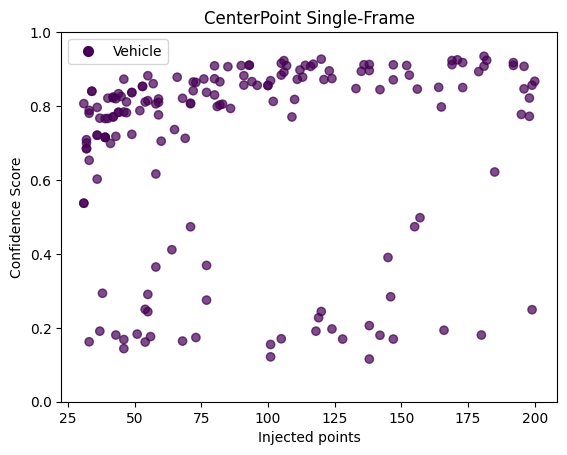

In [38]:
fig, ax = plt.subplots()

sc = ax.scatter(
    npoints,
    scores,
    c=labels,
    alpha=0.7
)

ax.set_xlabel("Injected points")
ax.set_ylabel("Confidence Score")
ax.set_title("CenterPoint Single-Frame")
ax.set_ylim(0, 1)

# Build legend using the SAME colormap + normalization
unique_labels = np.unique(labels)
class_names = {1: "Vehicle", 2: "Pedestrian", 3: "Cyclist"}

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        markerfacecolor=sc.cmap(sc.norm(l)),
        markeredgecolor='none',
        label=class_names[l]
    )
    for l in unique_labels
]

ax.legend(handles=handles)
plt.show()
fig.savefig('CPSF_score.png')

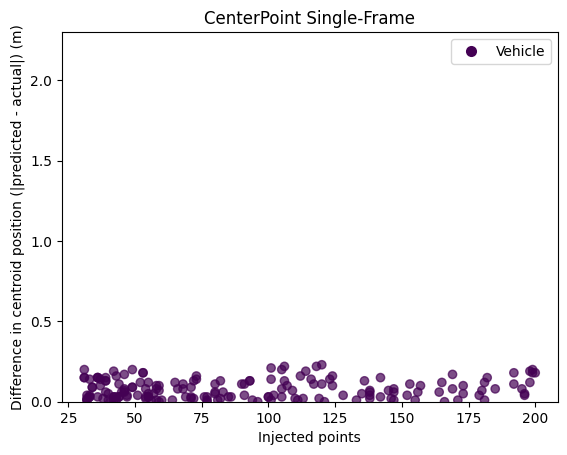

In [39]:
fig, ax = plt.subplots()

sc = ax.scatter(
    npoints,
    distances,
    c=labels,
    alpha=0.7
)


ax.set_xlabel("Injected points")
ax.set_ylabel("Difference in centroid position (|predicted - actual|) (m)")
ax.set_title("CenterPoint Single-Frame")
ax.set_ylim(0, 2.3)


ax.legend(handles=handles)
plt.show()
fig.savefig('CPSF_distance.png')

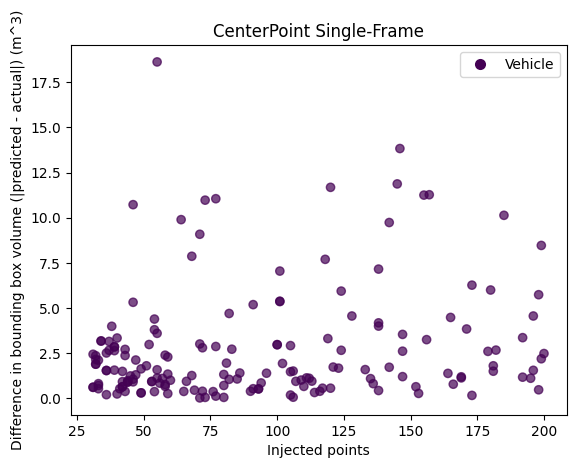

In [40]:
fig, ax = plt.subplots()

sc = ax.scatter(
    npoints,
    volumes,
    c=labels,
    alpha=0.7
)

ax.set_xlabel("Injected points")
ax.set_ylabel("Difference in bounding box volume (|predicted - actual|) (m^3)")
ax.set_title("CenterPoint Single-Frame")


ax.legend(handles=handles)
plt.show()
fig.savefig('CPSF_volume.png')

In [14]:
num_misclassified = 0
for label in labels:
    if label != 1: num_misclassified+=1
print((len(labels) - num_misclassified) / len(labels))

1.0


In [17]:
confident_threshold = 0.5
strong_threshold = 0.7
confident = []
strong = []
bins = []
classification = []
for i in range(3, 20):
    npoints =  [element for element in spoof_data if element['n_points'] >= (i*10) and element['n_points'] <= (i+1)*10]
    confident_bin = sum(1 for element in npoints if element['score']>confident_threshold) / len(npoints)
    strong_bin = sum(1 for element in npoints if element['score']>strong_threshold) / len(npoints)
    correctly_classified = sum(1 for element in npoints if element['label']==1) / len(npoints) 
    confident.append(confident_bin)
    strong.append(strong_bin)
    classification.append(correctly_classified)
    bins.append(f"{i*10} - {(i+1)*10}")

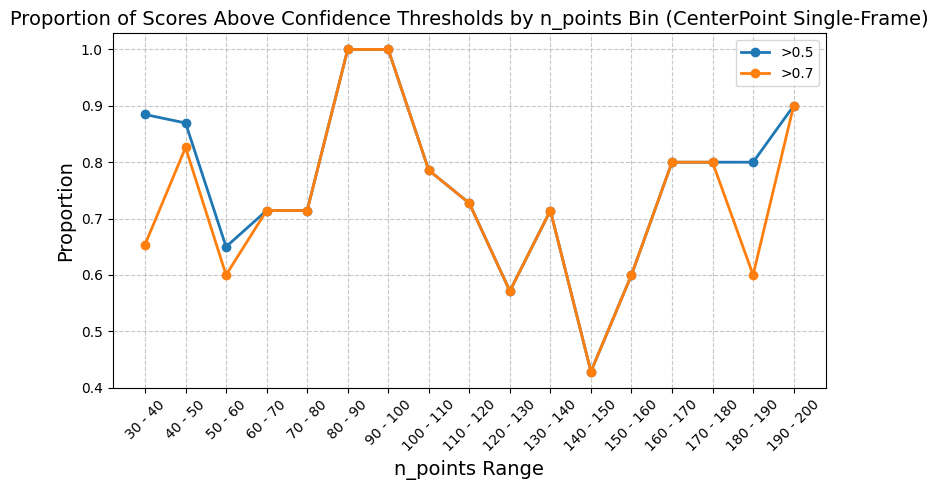

In [32]:
plt.figure(figsize=(8, 5))

# Plot 'Confident' line with dots
plt.plot(bins, confident, marker='o', linestyle='-', label='>0.5', linewidth=2)

# Plot 'Strong' line with dots
plt.plot(bins, strong, marker='o', linestyle='-', label='>0.7', linewidth=2)


# Customization
plt.title('Proportion of Scores Above Confidence Thresholds by n_points Bin (CenterPoint Single-Frame)', fontsize=14)
plt.xlabel('n_points Range', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.xticks(rotation=45) # Rotate bin labels for better readabilit
plt.legend()

# Add background grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

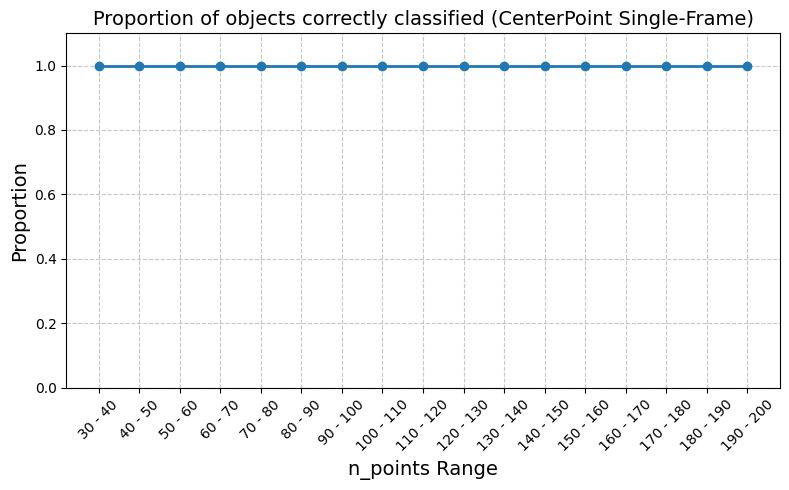

In [35]:
plt.figure(figsize=(8, 5))

# Plot 'Confident' line with dots
plt.plot(bins, classification, marker='o', linestyle='-', linewidth=2)

# Plot 'Strong' line with dots

# Customization
plt.title('Proportion of objects correctly classified (CenterPoint Single-Frame)', fontsize=14)
plt.xlabel('n_points Range', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.xticks(rotation=45) # Rotate bin labels for better readabilit
plt.ylim(0, 1.1)

# Add background grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [19]:
spoof_data

[{'box': tensor([14.8485, -3.0524,  0.9263], device='cuda:0'),
  'dim': tensor([4.6562, 2.0401, 1.5171], device='cuda:0'),
  'distance': 0.14,
  'cos_sim': tensor(1.0000, device='cuda:0'),
  'volume': 0.6,
  'label': 1,
  'score': 0.9036597013473511,
  'n_points': 93},
 {'box': tensor([14.8898, -3.0887,  1.0958], device='cuda:0'),
  'dim': tensor([4.7492, 2.1275, 1.7325], device='cuda:0'),
  'distance': 0.08,
  'cos_sim': tensor(0.9999, device='cuda:0'),
  'volume': 3.7,
  'label': 1,
  'score': 0.8171117305755615,
  'n_points': 34},
 {'box': tensor([14.7943, -3.3270,  0.9620], device='cuda:0'),
  'dim': tensor([4.5103, 2.0625, 1.5568], device='cuda:0'),
  'distance': 0.13,
  'cos_sim': tensor(0.9997, device='cuda:0'),
  'volume': 0.68,
  'label': 1,
  'score': 0.5257932543754578,
  'n_points': 31},
 {'box': tensor([15.0289, -2.8826,  0.7650], device='cuda:0'),
  'dim': tensor([4.3565, 2.0260, 1.4499], device='cuda:0'),
  'distance': 0.01,
  'cos_sim': tensor(1.0000, device='cuda:0'),


In [27]:
strong

[0.0,
 0.0,
 0.14285714285714285,
 0.30612244897959184,
 0.6857142857142857,
 0.5151515151515151,
 0.5714285714285714,
 0.4666666666666667,
 0.631578947368421,
 0.6470588235294118]